In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve)
from pyswarm import pso
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import BorderlineSMOTE
from sklearn.model_selection import train_test_split
import shap
import warnings

In [2]:
def _safe_auc(y_true, proba):
    y_true = np.asarray(y_true)
    if len(np.unique(y_true)) < 2:
        # fall back to 0.5 (random) if only one class present
        return 0.5
    return roc_auc_score(y_true, proba)

In [3]:
import os
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def _save_current_fig(filename):
    path = os.path.join(FIG_DIR, filename)
    try:
        plt.tight_layout()
    except Exception:
        pass
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"[Saved] {path}")

In [4]:
# --- Global toggles ---
OUTLIER_MODE   = "winsorize"   # {"winsorize","drop"}
CALIB_METHOD   = "isotonic"    # {"isotonic","sigmoid"}
THRESH_METRIC = "f1_macro"    # {"accuracy","f1_macro"}
# Optimize hyperparameters for ROC-AUC instead of accuracy
OPTIMIZE_FOR = "roc_auc"   # {"roc_auc", "accuracy"}
USE_GB_BASE = False
USE_GB_META    = False

In [5]:
# Pretty labels for plots
class _MockLE:
    classes_ = ['Non-Recurrence', 'Recurrence']
label_encoder = _MockLE()

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore', category=UserWarning, module='shap')
warnings.filterwarnings('ignore', category=FutureWarning)

In [6]:
# --- IQR helpers ---
def _iqr_bounds(s: pd.Series):
    q1 = s.quantile(0.25); q3 = s.quantile(0.75); iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

def apply_iqr_on_fold(X_tr: pd.DataFrame, y_tr: pd.Series, X_val: pd.DataFrame, strategy="winsorize"):
    """Compute IQR bounds on X_tr only. If 'drop', drop outlier rows in X_tr; 
       if 'winsorize', clip both X_tr and X_val to those bounds. Validation is never dropped."""
    X_tr = X_tr.copy(); X_val = X_val.copy(); y_tr = y_tr.copy()
    bounds = {}
    for c in X_tr.columns:
        # Skip if column is all NaN (can happen in weird data)
        if X_tr[c].isnull().all():
            continue
        lo, hi = _iqr_bounds(X_tr[c])
        bounds[c] = (lo, hi)

    if strategy == "drop":
        keep = np.ones(len(X_tr), dtype=bool)
        for c, (lo, hi) in bounds.items():
            keep &= (X_tr[c] >= lo) & (X_tr[c] <= hi)
        X_tr, y_tr = X_tr.loc[keep], y_tr.loc[keep]
        for c, (lo, hi) in bounds.items():
            X_val[c] = X_val[c].clip(lo, hi)
    else:
        for c, (lo, hi) in bounds.items():
            X_tr[c]  = X_tr[c].clip(lo, hi)
            X_val[c] = X_val[c].clip(lo, hi)
    return X_tr, y_tr, X_val, bounds

def apply_iqr_on_full_train_and_test(X_tr: pd.DataFrame, y_tr: pd.Series, X_te: pd.DataFrame, strategy="winsorize"):
    """Same idea for the final training phase (compute bounds on all training; never drop test)."""
    X_tr = X_tr.copy(); X_te = X_te.copy(); y_tr = y_tr.copy()
    bounds = {}
    for c in X_tr.columns:
        if X_tr[c].isnull().all():
            continue
        lo, hi = _iqr_bounds(X_tr[c]); bounds[c] = (lo, hi)

    if strategy == "drop":
        keep = np.ones(len(X_tr), dtype=bool)
        for c, (lo, hi) in bounds.items():
            keep &= (X_tr[c] >= lo) & (X_tr[c] <= hi)
        X_tr, y_tr = X_tr.loc[keep], y_tr.loc[keep]
        for c, (lo, hi) in bounds.items():
            X_te[c] = X_te[c].clip(lo, hi)
    else:
        for c, (lo, hi) in bounds.items():
            X_tr[c] = X_tr[c].clip(lo, hi)
            X_te[c] = X_te[c].clip(lo, hi)
    return X_tr, y_tr, X_te, bounds

In [7]:
# --- Threshold helper ---
from sklearn.metrics import f1_score

def find_best_threshold(y_true, scores, objective="accuracy"):
    thresholds = np.linspace(0.05, 0.95, 19)
    best_t, best_v = 0.5, -1.0
    for t in thresholds:
        preds = (scores >= t).astype(int)
        if objective == "accuracy":
            val = accuracy_score(y_true, preds)
        else:
            val = f1_score(y_true, preds, average="macro")
        if val > best_v:
            best_v, best_t = val, t
    return best_t, best_v

In [8]:
# --- 1. Load the dataset ---
# <<< MODIFIED >>> This block now loads 'prognostic.csv'
# It assumes the file HAS a header row, because the new preprocessing
# logic needs to find columns by name (e.g., 'Outcome', 'Lymph_node_status')
print("--- Loading Data ---")
try:
    prognostic = pd.read_csv("prognostic.csv")
    print("'prognostic.csv' loaded successfully.")
except FileNotFoundError:
    print("Error: 'prognostic.csv' not found. Please make sure the file is in the correct directory.")
    exit()
print(f"Loaded data with {prognostic.shape[0]} rows and {prognostic.shape[1]} columns.")
print("-" * 50)

--- Loading Data ---
'prognostic.csv' loaded successfully.
Loaded data with 198 rows and 35 columns.
--------------------------------------------------


In [9]:
# --- 2. Data Preprocessing ---
# <<< NEW >>> This block is based on your provided preprocessing logic.
print("\n--- Data Preprocessing ---")
initial_rows = len(prognostic)
# Replace '?' with NaN
prognostic.replace('?', np.nan, inplace=True)

# Force all non-target columns to numeric (coerce any str → NaN)
numeric_cols = prognostic.columns.drop(['Outcome'])
for col in numeric_cols:
    prognostic[col] = pd.to_numeric(prognostic[col], errors='coerce')

# DO NOT drop rows with NaN in Lymph_node_status; let the imputer handle them
# (no prognostic.dropna(subset=['Lymph_node_status']) here)

# Remove ID if present; drop 'Time' to avoid leakage
if 'ID' in prognostic.columns:
    prognostic.drop(columns=['ID'], inplace=True)

drop_cols = ['Outcome']
if 'Time' in prognostic.columns:
    drop_cols.append('Time')

X = prognostic.drop(columns=drop_cols, axis=1)
y = (prognostic['Outcome'] == 'R').astype(int)

# Drop columns that are entirely empty (rare safety check)
X.dropna(axis=1, how='all', inplace=True)

# <<< REMOVED >>> The leaky global imputation step was removed.
# The script's K-Fold pipeline (Cell 7) will handle the remaining NaNs
# correctly and safely (per-fold) using SimpleImputer.
print("Imputation will be handled within the cross-validation pipeline to prevent data leakage.")

print(f"Features shape: {X.shape}, Label distribution: {np.bincount(y)}")

# Check for the single-member class error *after* all filtering
class_counts = y.value_counts()
if (class_counts <= 1).any():
     print("\n!!! CRITICAL WARNING: After filtering, a class has 1 or 0 members. !!!")
     print(class_counts)
     print("This will cause train_test_split to fail. Your dataset is too small or imbalanced for this analysis.")
else:
    print("Class distribution is valid for splitting.")
    
print("-" * 50)

# Update Mock Label Encoder for plots
class MockLabelEncoder:
    classes_ = ['Non-Recurrence', 'Recurrence']
label_encoder = MockLabelEncoder()


--- Data Preprocessing ---
Imputation will be handled within the cross-validation pipeline to prevent data leakage.
Features shape: (198, 32), Label distribution: [151  47]
Class distribution is valid for splitting.
--------------------------------------------------


In [10]:
# --- 3. Split Data and Initialize K-Fold ---
print("\n--- Splitting Data and Initializing K-Fold ---")
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
y_train = pd.Series(y_train, index=X_train.index)
y_test = pd.Series(y_test, index=X_test.index)
print(f"Data split into training ({X_train.shape}) and testing ({X_test.shape}) sets.")

# <<< MODIFIED >>> Kept n_splits=5, as this dataset is very small and imbalanced
# This must be <= the number of samples in the smallest class
n_splits = min(10, y_train.value_counts().min())
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
print(f"Initialized StratifiedKFold with {n_splits} splits.")
print("-" * 30)


--- Splitting Data and Initializing K-Fold ---
Data split into training ((148, 32)) and testing ((50, 32)) sets.
Initialized StratifiedKFold with 10 splits.
------------------------------


In [11]:
# --- 4. K-Fold Cross-Validation for PSO Hyperparameter Tuning ---
print("\n--- Starting Cross-Validation for Hyperparameter Optimization ---")
all_rf_opt_params = []
all_svc_opt_params = []
all_knn_opt_params = []

for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train), 1):
    print(f"\nProcessing Fold {fold}/{n_splits} for PSO Tuning")
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold = y_train.iloc[train_index]
    y_val_fold   = y_train.iloc[val_index]

    # This imputer is now crucial for handling the NaNs
    imputer_fold = SimpleImputer(strategy='median')
    X_train_fold = pd.DataFrame(imputer_fold.fit_transform(X_train_fold),
                                columns=X_train.columns, index=X_train_fold.index)
    X_val_fold   = pd.DataFrame(imputer_fold.transform(X_val_fold),
                                columns=X_train.columns, index=X_val_fold.index)

    # now IQR on imputed data
    X_train_fold, y_train_fold, X_val_fold, _ = apply_iqr_on_fold(X_train_fold, y_train_fold, X_val_fold, strategy=OUTLIER_MODE)
    
    scaler = StandardScaler()
    X_train_scaled_fold = scaler.fit_transform(X_train_fold)
    X_val_scaled_fold = scaler.transform(X_val_fold)

    feature_selector_fold = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold="median")
    feature_selector_fold.fit(X_train_scaled_fold, y_train_fold)
    X_train_selected_fold = feature_selector_fold.transform(X_train_scaled_fold)
    X_val_selected_fold = feature_selector_fold.transform(X_val_scaled_fold)

    # Check if a class was dropped during IQR
    if len(np.unique(y_train_fold)) < 2:
        print(f"Skipping fold {fold}: IQR strategy '{OUTLIER_MODE}' removed all samples of one class.")
        continue
        
    borderline_smote = BorderlineSMOTE(random_state=42, kind='borderline-1')
    X_tr_res_fold, y_tr_res_fold = borderline_smote.fit_resample(X_train_selected_fold, y_train_fold)

    def rf_objective(params):
        n_estimators, max_depth, min_samples_split, min_samples_leaf = map(int, params)
        model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, min_samples_split=min_samples_split, 
                                       min_samples_leaf=min_samples_leaf, random_state=42, n_jobs=-1)
        model.fit(X_tr_res_fold, y_tr_res_fold)
        proba = model.predict_proba(X_val_selected_fold)[:, 1]
        return -_safe_auc(y_val_fold, proba)

    
    def svc_objective(params):
        C, gamma = params
        model = SVC(kernel='rbf', C=float(C), gamma=float(gamma), probability=True, random_state=42)
        model.fit(X_tr_res_fold, y_tr_res_fold)
        proba = model.predict_proba(X_val_selected_fold)[:, 1]
        return -_safe_auc(y_val_fold, proba)

    
    def knn_objective(params):
        n_neighbors, leaf_size = map(int, params)
        model = KNeighborsClassifier(n_neighbors=n_neighbors, leaf_size=leaf_size, n_jobs=-1)
        model.fit(X_tr_res_fold, y_tr_res_fold)
        proba = model.predict_proba(X_val_selected_fold)[:, 1]
        return -_safe_auc(y_val_fold, proba)
    
    # Reduced swarmsize/maxiter for faster tuning on small dataset
    swarmsize = 10
    maxiter = 50
    
    bounds = ([10, 3, 2, 1, 0.01, 0.5], [200, 20, 20, 20, 0.30, 1.0])
    svc_bounds_lo, svc_bounds_hi = [0.1, 1e-4], [100.0, 1.0]
    knn_bounds_lo, knn_bounds_hi = [3, 10], [31, 60]
    
    rf_opt_params, _ = pso(rf_objective, bounds[0][:4], bounds[1][:4], swarmsize=swarmsize, maxiter=maxiter, debug=False)
    svc_opt_params, _ = pso(svc_objective, svc_bounds_lo, svc_bounds_hi, swarmsize=swarmsize, maxiter=maxiter, debug=False)
    knn_opt_params, _ = pso(knn_objective, knn_bounds_lo, knn_bounds_hi, swarmsize=swarmsize, maxiter=maxiter, debug=False)
    
    all_rf_opt_params.append(rf_opt_params)
    all_svc_opt_params.append(svc_opt_params)
    all_knn_opt_params.append(knn_opt_params)
print("\n--- Hyperparameter Tuning Finished ---")
print("-" * 30)


--- Starting Cross-Validation for Hyperparameter Optimization ---

Processing Fold 1/10 for PSO Tuning
Stopping search: maximum iterations reached --> 50
Stopping search: maximum iterations reached --> 50
Stopping search: Swarm best objective change less than 1e-08

Processing Fold 2/10 for PSO Tuning
Stopping search: maximum iterations reached --> 50
Stopping search: maximum iterations reached --> 50
Stopping search: maximum iterations reached --> 50

Processing Fold 3/10 for PSO Tuning
Stopping search: maximum iterations reached --> 50
Stopping search: maximum iterations reached --> 50
Stopping search: maximum iterations reached --> 50

Processing Fold 4/10 for PSO Tuning
Stopping search: Swarm best objective change less than 1e-08
Stopping search: maximum iterations reached --> 50
Stopping search: maximum iterations reached --> 50

Processing Fold 5/10 for PSO Tuning
Stopping search: maximum iterations reached --> 50
Stopping search: Swarm best objective change less than 1e-08
Stop

In [12]:
# --- 5. Calculate Mean Optimized Hyperparameters ---
# (Using .any() to check if list is empty, otherwise np.mean fails)
mean_rf_n_estimators = int(np.mean([p[0] for p in all_rf_opt_params])) if all_rf_opt_params else 100
mean_rf_max_depth = int(np.mean([p[1] for p in all_rf_opt_params])) if all_rf_opt_params else 10
mean_rf_min_split = int(np.mean([p[2] for p in all_rf_opt_params])) if all_rf_opt_params else 2
mean_rf_min_leaf = int(np.mean([p[3] for p in all_rf_opt_params])) if all_rf_opt_params else 1
mean_svc_C = float(np.mean([p[0] for p in all_svc_opt_params])) if all_svc_opt_params else 1.0
mean_svc_gamma = float(np.mean([p[1] for p in all_svc_opt_params])) if all_svc_opt_params else 0.1
mean_knn_k = int(np.round(np.mean([p[0] for p in all_knn_opt_params]))) if all_knn_opt_params else 5
mean_knn_leaf_size = int(np.round(np.mean([p[1] for p in all_knn_opt_params]))) if all_knn_opt_params else 30

print("\n--- Mean Optimized Hyperparameters (Across Folds) ---")
print(f"(Hyperparameters optimized for ROC-AUC on validation folds)")
print(f"Random Forest: n_estimators={mean_rf_n_estimators}, max_depth={mean_rf_max_depth}, min_samples_split={mean_rf_min_split}, min_samples_leaf={mean_rf_min_leaf}")
print(f"SVC: C={mean_svc_C:.3f}, gamma={mean_svc_gamma:.5f}")
print(f"KNN: n_neighbors={mean_knn_k}, leaf_size={mean_knn_leaf_size}")
print("-" * 30)


--- Mean Optimized Hyperparameters (Across Folds) ---
(Hyperparameters optimized for ROC-AUC on validation folds)
Random Forest: n_estimators=72, max_depth=9, min_samples_split=10, min_samples_leaf=10
SVC: C=44.213, gamma=0.16347
KNN: n_neighbors=22, leaf_size=43
------------------------------


In [13]:
# --- 6. Generate Out-of-Fold (OOF) Predictions for Meta-Model Training ---
print("\n--- Generating Out-of-Fold Predictions for Meta-Model ---")
oof_rf_preds = np.zeros(X_train.shape[0])
oof_svc_preds = np.zeros(X_train.shape[0])
oof_knn_preds = np.zeros(X_train.shape[0])

# Store indices for OOF predictions
oof_indices = np.array([], dtype=int)


for fold, (train_index, val_index) in enumerate(skf.split(X_train, y_train), 1):
    print(f"Processing Fold {fold}/{n_splits} for OOF predictions...")
    X_train_fold, X_val_fold = X_train.iloc[train_index], X_train.iloc[val_index]
    y_train_fold = y_train.iloc[train_index]; y_val_fold = y_train.iloc[val_index]
    
    # Store the validation indices to align predictions later
    oof_indices = np.concatenate([oof_indices, val_index])

    imp_fold = SimpleImputer(strategy='median')
    X_train_fold = pd.DataFrame(imp_fold.fit_transform(X_train_fold),
                                columns=X_train.columns, index=X_train_fold.index)
    X_val_fold   = pd.DataFrame(imp_fold.transform(X_val_fold),
                                columns=X_train.columns, index=X_val_fold.index)

    X_train_fold, y_train_fold, X_val_fold, _ = apply_iqr_on_fold(X_train_fold, y_train_fold, X_val_fold, strategy=OUTLIER_MODE)

    scaler_fold = StandardScaler()
    X_train_scaled_fold = scaler_fold.fit_transform(X_train_fold)
    X_val_scaled_fold = scaler_fold.transform(X_val_fold)
    
    fs_fold = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold="median")
    fs_fold.fit(X_train_scaled_fold, y_train_fold)
    X_train_selected_fold = fs_fold.transform(X_train_scaled_fold)
    X_val_selected_fold   = fs_fold.transform(X_val_scaled_fold)
    
    # Check for dropped classes again
    if len(np.unique(y_train_fold)) < 2:
        print(f"Skipping fold {fold}: IQR strategy '{OUTLIER_MODE}' removed all samples of one class.")
        # We must fill the OOF preds for this fold with a default (e.g., 0.5)
        oof_rf_preds[val_index] = 0.5
        oof_svc_preds[val_index] = 0.5
        oof_knn_preds[val_index] = 0.5
        continue

    # Inner split on the fold’s TRAIN (after scaling+FS), BEFORE SMOTE
    X_tr_sel, y_tr_sel = X_train_selected_fold, y_train_fold
    
    # Check if inner split is possible
    if len(np.unique(y_tr_sel)) < 2 or y_tr_sel.value_counts().min() < 2:
        print(f"Skipping calibration for fold {fold}: Not enough samples in minority class for inner split.")
        # Fallback: Train on all fold data, no calibration
        X_tr_tr_res, y_tr_tr_res = BorderlineSMOTE(random_state=42, kind='borderline-1').fit_resample(X_tr_sel, y_tr_sel)
        
        rf_model_fold = RandomForestClassifier(n_estimators=mean_rf_n_estimators, max_depth=mean_rf_max_depth, min_samples_split=mean_rf_min_split, min_samples_leaf=mean_rf_min_leaf, random_state=42, n_jobs=-1).fit(X_tr_tr_res, y_tr_tr_res)
        svc_model_fold = SVC(kernel='rbf', C=mean_svc_C, gamma=mean_svc_gamma, probability=True, random_state=42).fit(X_tr_tr_res, y_tr_tr_res)
        knn_model_fold = KNeighborsClassifier(n_neighbors=mean_knn_k, leaf_size=mean_knn_leaf_size, n_jobs=-1).fit(X_tr_tr_res, y_tr_tr_res)
        
        # Use uncalibrated probabilities
        oof_rf_preds[val_index]  = rf_model_fold.predict_proba(X_val_selected_fold)[:, 1]
        oof_svc_preds[val_index] = svc_model_fold.predict_proba(X_val_selected_fold)[:, 1]
        oof_knn_preds[val_index] = knn_model_fold.predict_proba(X_val_selected_fold)[:, 1]
        continue

    # Proceed with calibration split
    X_tr_tr, X_tr_cal, y_tr_tr, y_tr_cal = train_test_split(X_tr_sel, y_tr_sel, test_size=0.20, stratify=y_tr_sel, random_state=42)

    smote_inner = BorderlineSMOTE(random_state=42, kind='borderline-1')
    X_tr_tr_res, y_tr_tr_res = smote_inner.fit_resample(X_tr_tr, y_tr_tr)

    rf_model_fold = RandomForestClassifier(n_estimators=mean_rf_n_estimators, max_depth=mean_rf_max_depth, min_samples_split=mean_rf_min_split, min_samples_leaf=mean_rf_min_leaf, random_state=42, n_jobs=-1).fit(X_tr_tr_res, y_tr_tr_res)
    svc_model_fold = SVC(kernel='rbf', C=mean_svc_C, gamma=mean_svc_gamma, probability=True, random_state=42).fit(X_tr_tr_res, y_tr_tr_res)
    knn_model_fold = KNeighborsClassifier(n_neighbors=mean_knn_k, leaf_size=mean_knn_leaf_size, n_jobs=-1).fit(X_tr_tr_res, y_tr_tr_res)
    
    rf_cal_fold  = CalibratedClassifierCV(rf_model_fold,  method=CALIB_METHOD, cv='prefit').fit(X_tr_cal, y_tr_cal)
    svc_cal_fold = CalibratedClassifierCV(svc_model_fold, method=CALIB_METHOD, cv='prefit').fit(X_tr_cal, y_tr_cal)
    knn_cal_fold = CalibratedClassifierCV(knn_model_fold, method=CALIB_METHOD, cv='prefit').fit(X_tr_cal, y_tr_cal)

    oof_rf_preds[val_index]  = rf_cal_fold.predict_proba(X_val_selected_fold)[:, 1]
    oof_svc_preds[val_index] = svc_cal_fold.predict_proba(X_val_selected_fold)[:, 1]
    oof_knn_preds[val_index] = knn_cal_fold.predict_proba(X_val_selected_fold)[:, 1]

print("OOF Prediction Generation Complete.")

y_train_sorted = y_train.reindex(X_train.index)

meta_features_train_oof = np.column_stack((oof_rf_preds, oof_svc_preds, oof_knn_preds))

meta_model_lr = LogisticRegression(random_state=42)
meta_model_lr.fit(meta_features_train_oof, y_train_sorted)

oof_meta_proba_lr = meta_model_lr.predict_proba(meta_features_train_oof)[:, 1]
best_thr_lr, _ = find_best_threshold(y_train_sorted, oof_meta_proba_lr, THRESH_METRIC)

print(f"Best OOF threshold (LR, {THRESH_METRIC}): {best_thr_lr:.3f}")

# --- NEW: per-base thresholds from OOF ---
best_thr_rf,  _ = find_best_threshold(y_train_sorted, oof_rf_preds,  THRESH_METRIC)
best_thr_svc, _ = find_best_threshold(y_train_sorted, oof_svc_preds, THRESH_METRIC)
best_thr_knn, _ = find_best_threshold(y_train_sorted, oof_knn_preds, THRESH_METRIC)

print(f"Best OOF threshold (RF,  {THRESH_METRIC}): {best_thr_rf:.3f}")
print(f"Best OOF threshold (SVC, {THRESH_METRIC}): {best_thr_svc:.3f}")
print(f"Best OOF threshold (KNN, {THRESH_METRIC}): {best_thr_knn:.3f}")

print("-" * 30)


--- Generating Out-of-Fold Predictions for Meta-Model ---
Processing Fold 1/10 for OOF predictions...


C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Processing Fold 2/10 for OOF predictions...


C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Processing Fold 3/10 for OOF predictions...


...

C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Processing Fold 9/10 for OOF predictions...


C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


Processing Fold 10/10 for OOF predictions...
OOF Prediction Generation Complete.
Best OOF threshold (LR, f1_macro): 0.300
Best OOF threshold (RF,  f1_macro): 0.400
Best OOF threshold (SVC, f1_macro): 0.300
Best OOF threshold (KNN, f1_macro): 0.350
------------------------------


C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [14]:
# --- 7. Train Final Base Models and Meta-Model ---
print("\n--- Training Final Models ---")

# (A) Impute first (fit on TRAIN only, apply to TEST)
imputer_final = SimpleImputer(strategy='median')
X_train_imp = pd.DataFrame(imputer_final.fit_transform(X_train),
                           columns=X_train.columns, index=X_train.index)
X_test_imp  = pd.DataFrame(imputer_final.transform(X_test),
                           columns=X_test.columns, index=X_test.index)

# (B) IQR on the imputed data (compute bounds on TRAIN; never drop TEST)
X_train_iqr, y_train_iqr, X_test_iqr, _ = apply_iqr_on_full_train_and_test(
    X_train_imp, y_train, X_test_imp, strategy=OUTLIER_MODE
)

# (C) Scale (fit on TRAIN only, apply to TEST)
scaler_final = StandardScaler()
X_train_scaled_final = scaler_final.fit_transform(X_train_iqr)
X_test_scaled_final  = scaler_final.transform(X_test_iqr)

# (D) Feature Select (fit on TRAIN only, apply to TEST)
feature_selector_final = SelectFromModel(
    RandomForestClassifier(n_estimators=100, random_state=42), threshold="median"
)
feature_selector_final.fit(X_train_scaled_final, y_train_iqr)
X_train_selected_final = feature_selector_final.transform(X_train_scaled_final)
X_test_selected_final  = feature_selector_final.transform(X_test_scaled_final)

selected_feature_indices = feature_selector_final.get_support(indices=True)
selected_feature_names = X.columns[selected_feature_indices]
print(f"Selected feature names: {list(selected_feature_names)}")

# After you have X_train_selected_final, y_train_iqr:
from sklearn.model_selection import StratifiedShuffleSplit
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
(tr_idx, cal_idx), = sss.split(X_train_selected_final, y_train_iqr)
X_tr_sel_cal, y_tr_sel_cal = X_train_selected_final[tr_idx], y_train_iqr.iloc[tr_idx]
X_cal, y_cal               = X_train_selected_final[cal_idx], y_train_iqr.iloc[cal_idx]

# SMOTE on training slice only
borderline_smote_final = BorderlineSMOTE(random_state=42, kind='borderline-1')
X_train_resampled_final, y_train_resampled_final = borderline_smote_final.fit_resample(
    X_tr_sel_cal, y_tr_sel_cal
)

# Fit uncalibrated base models on SMOTE'd train-slice
rf_final = RandomForestClassifier(
    n_estimators=mean_rf_n_estimators, max_depth=mean_rf_max_depth,
    min_samples_split=mean_rf_min_split, min_samples_leaf=mean_rf_min_leaf,
    random_state=42, n_jobs=-1
).fit(X_train_resampled_final, y_train_resampled_final)

svc_final = SVC(kernel='rbf', C=mean_svc_C, gamma=mean_svc_gamma, probability=True, random_state=42)\
    .fit(X_train_resampled_final, y_train_resampled_final)

knn_final = KNeighborsClassifier(n_neighbors=mean_knn_k, leaf_size=mean_knn_leaf_size, n_jobs=-1)\
    .fit(X_train_resampled_final, y_train_resampled_final)

# Calibrate on untouched calibration slice (original distribution)
rf_cal_final  = CalibratedClassifierCV(rf_final,  method=CALIB_METHOD, cv='prefit').fit(X_cal, y_cal)
svc_cal_final = CalibratedClassifierCV(svc_final, method=CALIB_METHOD, cv='prefit').fit(X_cal, y_cal)
knn_cal_final = CalibratedClassifierCV(knn_final, method=CALIB_METHOD, cv='prefit').fit(X_cal, y_cal)
print("Final uncalibrated trees fitted (for SHAP) and calibrated copies fitted (for prediction).")
print("-" * 30)


--- Training Final Models ---
Selected feature names: ['radius1', 'texture1', 'smoothness1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'compactness2', 'radius3', 'perimeter3', 'area3', 'smoothness3', 'symmetry3', 'Tumor_size', 'Lymph_node_status']
Final uncalibrated trees fitted (for SHAP) and calibrated copies fitted (for prediction).
------------------------------


C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
C:\Users\Rahul\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(


In [15]:
# --- 8. Performance Evaluation on the Test Set ---
print("\n--- Evaluating Models on the Test Set ---")

# Get calibrated base probabilities on test
y_proba_rf_test  = rf_cal_final.predict_proba(X_test_selected_final)[:, 1]
y_proba_svc_test = svc_cal_final.predict_proba(X_test_selected_final)[:, 1]
y_proba_knn_test = knn_cal_final.predict_proba(X_test_selected_final)[:, 1]

# Create meta-features for the test set
meta_features_test = np.column_stack((y_proba_rf_test, y_proba_svc_test, y_proba_knn_test))

# --- Meta-Model (LR) Predictions ---
y_proba_meta_lr_test = meta_model_lr.predict_proba(meta_features_test)[:, 1]
y_pred_meta_lr_test  = (y_proba_meta_lr_test >= best_thr_lr).astype(int)

print("\n--- Meta-Model (LR, threshold from OOF): Test Set ---")
print(f"Threshold used: {best_thr_lr:.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_meta_lr_test):.4f}, "
      f"F1: {f1_score(y_test, y_pred_meta_lr_test):.4f}, "
      f"ROC AUC: {roc_auc_score(y_test, y_proba_meta_lr_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_meta_lr_test, zero_division=0):.4f}, "
      f"Recall (Sensitivity): {recall_score(y_test, y_pred_meta_lr_test):.4f}")

# --- Base Model Predictions (for comparison) ---
y_pred_rf_test  = (y_proba_rf_test  >= best_thr_rf).astype(int)
y_pred_svc_test = (y_proba_svc_test >= best_thr_svc).astype(int)
y_pred_knn_test = (y_proba_knn_test >= best_thr_knn).astype(int)

print("\n--- Random Forest (Calibrated, OOF-thr): Test Set ---")
print(f"Threshold used: {best_thr_rf:.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_test):.4f}, "
      f"F1: {f1_score(y_test, y_pred_rf_test):.4f}, "
      f"ROC AUC: {roc_auc_score(y_test, y_proba_rf_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf_test, zero_division=0):.4f}, "
      f"Recall (Sensitivity): {recall_score(y_test, y_pred_rf_test):.4f}")

print("\n--- SVC (Calibrated, OOF-thr): Test Set ---")
print(f"Threshold used: {best_thr_svc:.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svc_test):.4f}, "
      f"F1: {f1_score(y_test, y_pred_svc_test):.4f}, "
      f"ROC AUC: {roc_auc_score(y_test, y_proba_svc_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_svc_test, zero_division=0):.4f}, "
      f"Recall (Sensitivity): {recall_score(y_test, y_pred_svc_test):.4f}")

print("\n--- KNN (Calibrated, OOF-thr): Test Set ---")
print(f"Threshold used: {best_thr_knn:.3f}")
print(f"Accuracy: {accuracy_score(y_test, y_pred_knn_test):.4f}, "
      f"F1: {f1_score(y_test, y_pred_knn_test):.4f}, "
      f"ROC AUC: {roc_auc_score(y_test, y_proba_knn_test):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn_test, zero_division=0):.4f}, "
      f"Recall (Sensitivity): {recall_score(y_test, y_pred_knn_test):.4f}")
print("-" * 30)


--- Evaluating Models on the Test Set ---

--- Meta-Model (LR, threshold from OOF): Test Set ---
Threshold used: 0.300
Accuracy: 0.7400, F1: 0.2353, ROC AUC: 0.5746
Precision: 0.4000, Recall (Sensitivity): 0.1667

--- Random Forest (Calibrated, OOF-thr): Test Set ---
Threshold used: 0.400
Accuracy: 0.7200, F1: 0.2222, ROC AUC: 0.5384
Precision: 0.3333, Recall (Sensitivity): 0.1667

--- SVC (Calibrated, OOF-thr): Test Set ---
Threshold used: 0.300
Accuracy: 0.7600, F1: 0.2500, ROC AUC: 0.6031
Precision: 0.5000, Recall (Sensitivity): 0.1667

--- KNN (Calibrated, OOF-thr): Test Set ---
Threshold used: 0.350
Accuracy: 0.7600, F1: 0.3333, ROC AUC: 0.5680
Precision: 0.5000, Recall (Sensitivity): 0.2500
------------------------------


[Saved] figures\cm_meta_lr.png


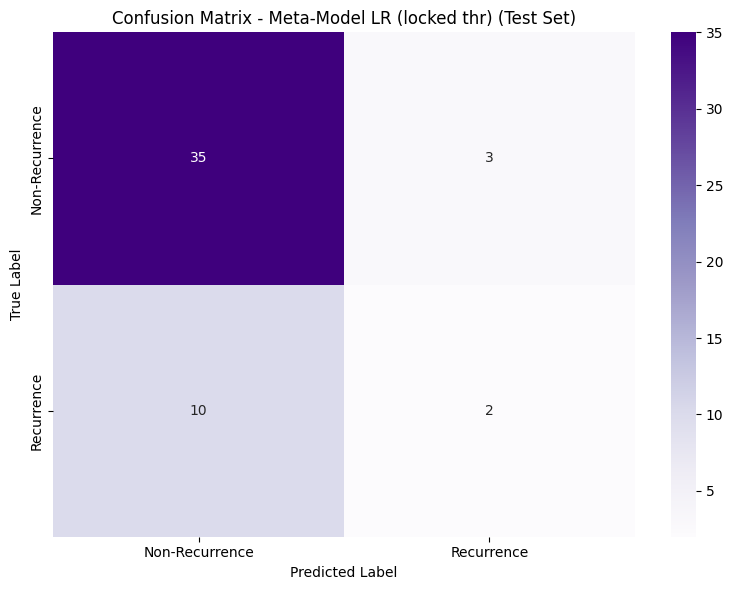

[Saved] figures\cm_rf.png


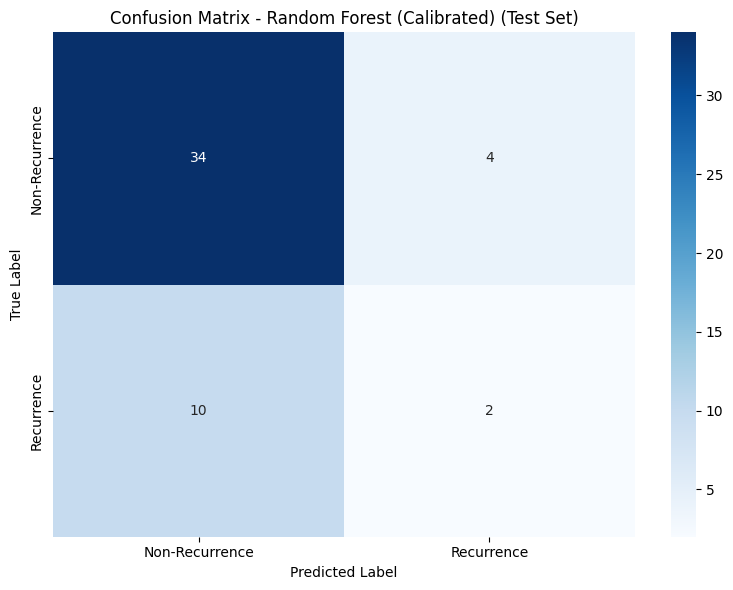

[Saved] figures\cm_svc.png


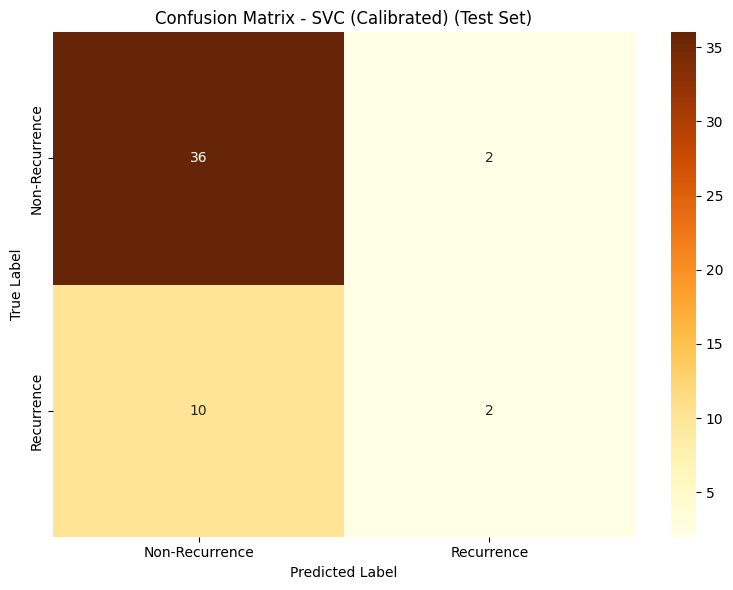

[Saved] figures\cm_knn.png


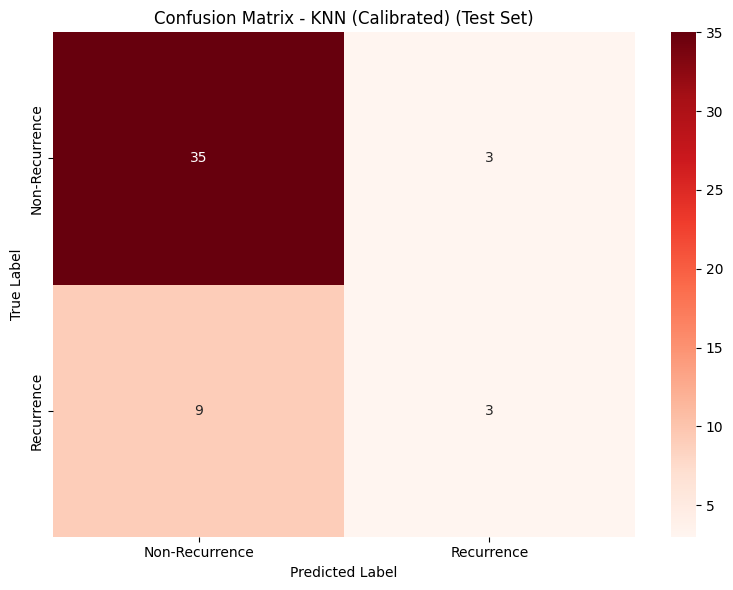

[Saved] figures\roc_test.png


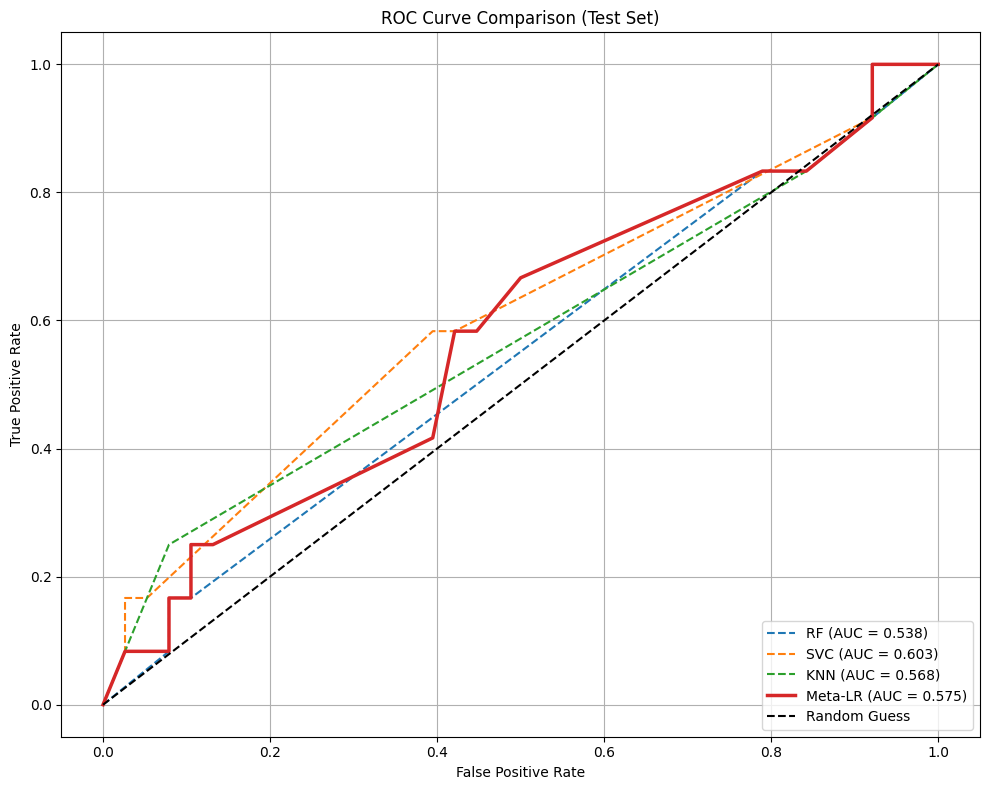

------------------------------


In [16]:
# --- 9. Plot Confusion Matrices and ROC Curve ---
def plot_confusion_matrix(y_true, y_pred, model_name, cmap, save_as=None):
    matrix = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt="d", cmap=cmap,
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.xlabel("Predicted Label"); plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {model_name} (Test Set)")
    if save_as:
        _save_current_fig(save_as)
    plt.show()

plot_confusion_matrix(y_test, y_pred_meta_lr_test, "Meta-Model LR (locked thr)", "Purples", save_as="cm_meta_lr.png")
plot_confusion_matrix(y_test, y_pred_rf_test,  "Random Forest (Calibrated)", "Blues",   save_as="cm_rf.png")
plot_confusion_matrix(y_test, y_pred_svc_test, "SVC (Calibrated)",          "YlOrBr",  save_as="cm_svc.png")
plot_confusion_matrix(y_test, y_pred_knn_test, "KNN (Calibrated)",          "Reds",    save_as="cm_knn.png")


# ROC curves (use probabilities)
plt.figure(figsize=(10, 8))
fpr_rf,   tpr_rf,   _ = roc_curve(y_test, y_proba_rf_test)
fpr_meta_lr, tpr_meta_lr, _ = roc_curve(y_test, y_proba_meta_lr_test)
fpr_svc, tpr_svc, _ = roc_curve(y_test, y_proba_svc_test)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn_test)

plt.plot(fpr_rf, tpr_rf,       label=f'RF (AUC = {roc_auc_score(y_test, y_proba_rf_test):.3f})',  linestyle='--')
plt.plot(fpr_svc, tpr_svc, label=f'SVC (AUC = {roc_auc_score(y_test, y_proba_svc_test):.3f})', linestyle='--')
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {roc_auc_score(y_test, y_proba_knn_test):.3f})', linestyle='--')
plt.plot(fpr_meta_lr, tpr_meta_lr, label=f'Meta-LR (AUC = {roc_auc_score(y_test, y_proba_meta_lr_test):.3f})', linewidth=2.5)

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate'); plt.title('ROC Curve Comparison (Test Set)')
plt.legend(loc='lower right'); plt.grid(True)
_save_current_fig("roc_test.png")
plt.show()
print("-" * 30)


--- SHAP Analysis ---

Generating SHAP analysis for Random Forest (uncalibrated)...
Plotting SHAP beeswarm for Random Forest (uncalibrated)...
[Saved] figures\shap_beeswarm_Random_Forest_uncalibrated.png


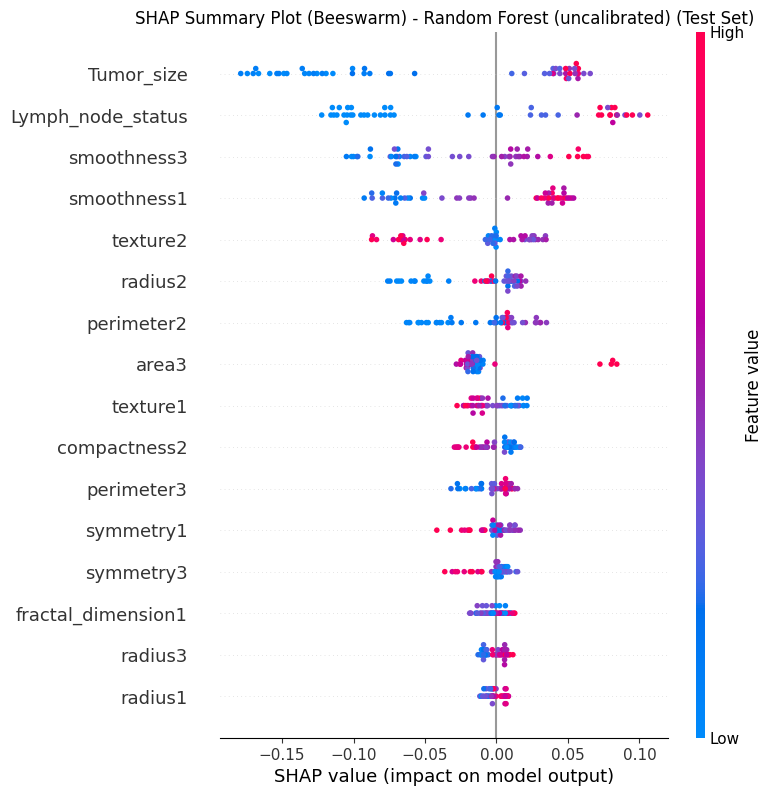

Plotting SHAP bar plot for Random Forest (uncalibrated)...
[Saved] figures\shap_bar_Random_Forest_uncalibrated.png


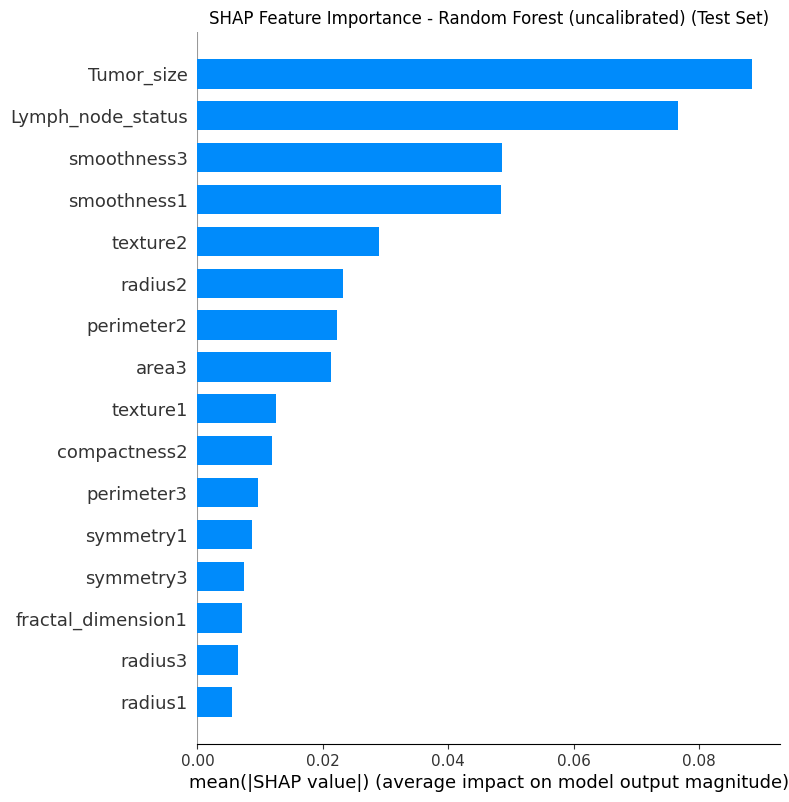

--------------------------------------------------

--- Analysis Complete ---


In [17]:
# --- 10. SHAP Analysis ---
def plot_shap_analysis(model, X_selected_test_data, feature_names_list, model_name):
    if model is None:
        print(f"Skipping SHAP for {model_name} as model is not trained.")
        return
        
    print(f"\nGenerating SHAP analysis for {model_name}...")
    if isinstance(X_selected_test_data, pd.DataFrame):
        X_selected_test_data_np = X_selected_test_data.values
    else:
        X_selected_test_data_np = X_selected_test_data

    try:
        explainer = shap.TreeExplainer(model)
        shap_values_test = explainer.shap_values(X_selected_test_data_np)
    except Exception as e:
        print(f"Error creating SHAP explainer or values for {model_name}: {e}")
        return

    shap_values_for_plot = None
    if isinstance(shap_values_test, list):
        if len(shap_values_test) == 2:
            shap_values_for_plot = shap_values_test[1] # Use values for the positive class
    elif isinstance(shap_values_test, np.ndarray):
        if shap_values_test.ndim == 2:
            shap_values_for_plot = shap_values_test
        elif shap_values_test.ndim == 3 and shap_values_test.shape[2] == 2:
            shap_values_for_plot = shap_values_test[:, :, 1] # Use values for the positive class

    if shap_values_for_plot is not None:
        # Create a DataFrame for SHAP to preserve feature names
        X_test_df_for_shap = pd.DataFrame(X_selected_test_data_np, columns=feature_names_list)
        
        # Beeswarm Summary Plot
        print(f"Plotting SHAP beeswarm for {model_name}...")
        try:
            shap.summary_plot(shap_values_for_plot, X_test_df_for_shap, show=False)
            _save_current_fig(f"shap_beeswarm_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.png")
            plt.title(f"SHAP Summary Plot (Beeswarm) - {model_name} (Test Set)")
            plt.show()
        except Exception as e:
            print(f"Error during SHAP beeswarm plot: {e}")
        finally:
            plt.close('all')

        # Bar Plot (Feature Importance)
        print(f"Plotting SHAP bar plot for {model_name}...")
        try:
            shap.summary_plot(shap_values_for_plot, X_test_df_for_shap, plot_type="bar", show=False)
            _save_current_fig(f"shap_bar_{model_name.replace(' ', '_').replace('(', '').replace(')', '')}.png")
            plt.title(f"SHAP Feature Importance - {model_name} (Test Set)")
            plt.show()
        except Exception as e:
            print(f"Error during SHAP bar plot: {e}")
        finally:
            plt.close('all')
    else:
        print(f"ERROR: Cannot proceed with SHAP plots for {model_name}. Check shap_values structure.")

print("\n--- SHAP Analysis ---")
if 'selected_feature_names' in locals() and not selected_feature_names.empty:
    selected_feature_names_list = list(selected_feature_names)

    plot_shap_analysis(rf_final, X_test_selected_final, selected_feature_names_list, "Random Forest (uncalibrated)")
else:
    print("Skipping SHAP analysis as no features were selected or models were not trained.")
print("-" * 50)

print("\n--- Analysis Complete ---")